# Geometric Position Encoding Ablation (v5)

Comparing position encoding methods across softmax and linear attention, with two novel
architectures inspired by gauge theory and sparse distributed memory.

## Methods

```
RoPE:       θ[t] = t · freq                              # fixed, abelian
CARoPE:     θ[t] = cumsum(1/(softplus(xW)+1)) · freq     # content-dep, 1 scalar/head
CDRoPE:     θ[t] = t · freq + cumsum(f(content))          # content-dep, per-dim (prior run)
HoloRoPE:   W[t] = exp(A_base + A_content[t]) @ W[t-1]   # SO(K) non-abelian (prior run)
CurvBias:   CDRoPE + ||θ_t - θ_s|| as attention bias      # curvature = context distance
NormHolo:   HoloRoPE + QK L2-norm + learnable temperature  # SDM-inspired retrieval
```

## Models in this run

| # | Model | Position Encoding | Attention | What it tests |
|---|---|---|---|---|
| 1 | GPT | Learned emb | Softmax | Baseline |
| 2 | GPT+RoPE | Fixed rotary | Softmax | Standard (LLaMA-style) |
| 3 | GPT+CARoPE | Content freq (1/head) | Softmax | Veisi & Fartoot 2025 |
| 4 | GPT+CurvBias | CDRoPE + curvature bias | Softmax | **Novel**: gauge-theory attention bias |
| 5 | GPT+NormHolo | SO(K) + QK-norm | Softmax | **Novel**: SDM-compatible holonomy |
| 6 | GLA | Learned emb | Linear | Baseline |
| 7 | GLA+RoPE | Fixed rotary | Linear | Standard |
| 8 | GLA+CARoPE | Content freq (1/head) | Linear | CARoPE on linear attention |
| 9 | GLA+CurvBias | CDRoPE + curvature bias | Linear | **Novel**: curvature bias on linear |
| 10 | GLA+NormHolo | SO(K) + QK-norm | Linear | **Novel**: SDM holonomy on linear |

## Prior results (from earlier run, same config)

| Model | PPL | Acc | Notes |
|---|---|---|---|
| GPT+CDRoPE | 76.3 | 30.4% | Abelian content-dep rotary (≈CARoPE) |
| GPT+HoloRoPE | 73.0 | 30.8% | Non-abelian SO(K) — best so far |
| GLA+RoPE | 76.1 | 30.6% | CDRoPE/HoloRoPE matched this |

## Novel architecture motivations

**CurvBias** — From the gauge fiber bundle geometry paper (ICLR 2025): attention induces
a connection with nonzero curvature. The curvature measures "context sensitivity" between
positions. We make this explicit by adding `||θ_t - θ_s||` (the field strength of the
content-dependent connection) as a learnable attention bias. Like ALiBi but content-aware.

**NormHolo** — From Bricken & Pehlevan (NeurIPS 2021): attention approximates Sparse
Distributed Memory when Q/K are L2-normalized. Our SO(K) holonomy preserves norms by
construction (orthogonal transport). Combining QK-normalization with holonomic rotation
gives SDM-compatible, path-dependent associative memory retrieval.

**Prior work**:
- **RoPE** (Su et al. 2021): fixed rotary. Flat U(1) connection.
- **CARoPE** (Veisi & Fartoot, July 2025): content-dependent cumsum frequencies.
- **CoPE** (Meta, 2024): gated position counts. Different mechanism.
- **LieRE** (ICML 2025): learnable SO(K), position-only (not content-dependent).
- **Gauge bundle paper** (ICLR 2025): proves attention is an Ehresmann connection with nonzero curvature.
- **Bricken & Pehlevan** (NeurIPS 2021): attention ≈ SDM under L2 normalization.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm.auto import tqdm
import math
import time
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

try:
    from datasets import load_dataset
    print("Loading WikiText-103...")
    ds = load_dataset("wikitext", "wikitext-103-raw-v1")
    train_text = "\n".join(ds["train"]["text"])
    val_text = "\n".join(ds["validation"]["text"])
except ImportError:
    raise ImportError("pip install datasets")

try:
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    vocab_size = enc.n_vocab
except ImportError:
    from transformers import GPT2TokenizerFast
    enc = GPT2TokenizerFast.from_pretrained("gpt2")
    vocab_size = enc.vocab_size

def tokenize(text):
    if hasattr(enc, 'encode_ordinary'):
        return enc.encode_ordinary(text)
    if hasattr(enc, 'encode'):
        return enc.encode(text)
    return enc(text)['input_ids']

print("Tokenizing...")
train_ids = torch.tensor(tokenize(train_text), dtype=torch.long)
val_ids = torch.tensor(tokenize(val_text), dtype=torch.long)
print(f"Train: {len(train_ids):,} tokens, Val: {len(val_ids):,} tokens, Vocab: {vocab_size:,}")

Device: cuda
Loading WikiText-103...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing...
Train: 118,496,151 tokens, Val: 248,461 tokens, Vocab: 50,257


In [21]:
@dataclass
class AblationConfig:
    d_model: int = 512
    n_heads: int = 8
    head_dim: int = 64
    holo_K: int = 8                # SO(K) block size for HoloRoPE
    conv_kernel: int = 4           # short causal conv for GLA

    ffn_mult: int = 4
    n_blocks: int = 8
    vocab_size: int = 50257
    max_seq_len: int = 1024
    dropout: float = 0.1

    learning_rate: float = 7e-4
    min_lr: float = 5e-5
    warmup_steps: int = 1000
    lr_hold_steps: int = 7000
    batch_size: int = 4
    seq_len: int = 1024
    max_steps: int = 20000
    eval_interval: int = 1000
    eval_steps: int = 100

cfg = AblationConfig(vocab_size=vocab_size)
n_holo_blocks = cfg.head_dim // cfg.holo_K
n_skew = cfg.holo_K * (cfg.holo_K - 1) // 2
print(f"Config: d={cfg.d_model} heads={cfg.n_heads} hd={cfg.head_dim} holo_K={cfg.holo_K}")
print(f"  SO({cfg.holo_K}) blocks per head: {n_holo_blocks}, skew params per block: {n_skew}")
print(f"  Conv kernel: {cfg.conv_kernel}, Blocks: {cfg.n_blocks}, LR: {cfg.learning_rate}")

def get_batch(data, c):
    ix = torch.randint(0, len(data) - c.seq_len - 1, (c.batch_size,))
    return torch.stack([data[i:i+c.seq_len] for i in ix]).to(device)

Config: d=512 heads=8 hd=64 holo_K=8
  SO(8) blocks per head: 8, skew params per block: 28
  Conv kernel: 4, Blocks: 8, LR: 0.0007


## Shared Utilities: SO(K) Holonomy + Rotary Encoding

In [22]:
def apply_rotary(x, cos_t, sin_t):
    """Standard rotary embedding. x: (B, H, T, d), cos/sin: (..., d/2)."""
    d2 = x.shape[-1] // 2
    x1, x2 = x[..., :d2], x[..., d2:]
    return torch.cat([x1 * cos_t - x2 * sin_t, x1 * sin_t + x2 * cos_t], dim=-1)


def skew_index(i, j, K):
    """Index in upper-triangle flattening for pair (i,j) with i < j."""
    return i * K - i * (i + 1) // 2 + (j - i - 1)


def make_skew_symmetric(params, K):
    """Map (..., K*(K-1)/2) params to (..., K, K) skew-symmetric matrices."""
    shape = params.shape[:-1]
    A = torch.zeros(*shape, K, K, device=params.device, dtype=params.dtype)
    ptr = 0
    for i in range(K):
        for j in range(i + 1, K):
            A[..., i, j] = params[..., ptr]
            A[..., j, i] = -params[..., ptr]
            ptr += 1
    return A


def fast_orthogonal(A):
    """exp(A) for small skew-symmetric A via 4-term Taylor. MPS-safe.
    Accurate to ~1e-8 when ||A|| < 0.1."""
    K = A.shape[-1]
    I = torch.eye(K, device=A.device, dtype=A.dtype)
    A2 = A @ A
    return I + A + A2 / 2 + (A2 @ A) / 6


def holonomy_parallel_scan(U_all):
    """Parallel prefix scan for matrix products: W[t] = U[t] @ W[t-1].
    Input/output: (N, T, K, K). O(T log T) matrix multiplies."""
    N, T, K, _ = U_all.shape
    W = U_all.clone()
    for s in range(int(math.ceil(math.log2(T)))):
        step = 2 ** s
        if step >= T:
            break
        W = torch.cat([W[:, :step], W[:, step:] @ W[:, :-step]], dim=1)
    return W


class HolonomicRotary(nn.Module):
    """Content-dependent SO(K) block rotation for q and k.

    Divides head_dim into blocks of K dimensions. Each block gets an independent
    SO(K) rotation accumulated from content via parallel scan.

    At init (zero content weights): reduces to a fixed rotation with RoPE-like
    frequency progression — the model starts with standard position encoding.
    During training: content modulates the rotation, making position encoding
    path-dependent and non-abelian.
    """
    def __init__(self, d_model, n_heads, head_dim, holo_K):
        super().__init__()
        K = holo_K
        nb = head_dim // K         # blocks per head
        ns = K * (K - 1) // 2      # skew params per block

        # Content → skew-symmetric params (zero-init: starts as base rotation only)
        self.holo_proj = nn.Linear(d_model, n_heads * nb * ns)
        nn.init.zeros_(self.holo_proj.weight)
        nn.init.zeros_(self.holo_proj.bias)

        # Base rotation: RoPE-like frequencies on canonical planes
        # Canonical planes: (0,1), (2,3), (4,5), ... within each K-block
        base = torch.zeros(nb, ns)
        for b in range(nb):
            for p in range(K // 2):
                global_plane = b * (K // 2) + p
                freq = 1.0 / (10000.0 ** (2.0 * global_plane / head_dim))
                idx = skew_index(2 * p, 2 * p + 1, K)
                base[b, idx] = freq
        self.register_buffer('base_skew', base)   # (nb, ns)

        self.H = n_heads
        self.K = K
        self.nb = nb
        self.ns = ns
        self.hd = head_dim

    def forward(self, x, q, k):
        """Apply holonomic rotation to q and k.
        x: (B, T, D) for content projection.
        q, k: (B, H, T, hd).
        Returns: rotated (q, k) with same shape.
        """
        B, T, _ = x.shape
        H, K, nb, ns = self.H, self.K, self.nb, self.ns

        # Content contribution
        content = self.holo_proj(x).reshape(B, T, H, nb, ns)

        # Total = base + content, scaled for Taylor accuracy
        # base_skew: (nb, ns) → broadcast to (1, 1, 1, nb, ns)
        total = (self.base_skew + content) * 0.01

        # Skew-symmetric → orthogonal
        flat = total.reshape(B * T * H * nb, ns)
        A = make_skew_symmetric(flat, K)
        U = fast_orthogonal(A).reshape(B, T, H * nb, K, K)

        # Parallel scan: W[t] = U[t] @ ... @ U[1]
        U_scan = U.permute(0, 2, 1, 3, 4).reshape(B * H * nb, T, K, K)
        W_scan = holonomy_parallel_scan(U_scan)

        # Causal shift: position t uses holonomy from tokens before t
        eye = torch.eye(K, device=x.device, dtype=x.dtype)
        eye = eye.reshape(1, 1, K, K).expand(B * H * nb, 1, K, K)
        W_scan = torch.cat([eye, W_scan[:, :-1]], dim=1)

        # Reshape: (B, H, nb, T, K, K)
        W = W_scan.reshape(B, H, nb, T, K, K)

        # Block-wise rotation of q and k
        # q: (B, H, T, hd) → (B, H, T, nb, K) → (B, H, nb, T, K)
        q_blk = q.reshape(B, H, T, nb, K).permute(0, 1, 3, 2, 4)
        k_blk = k.reshape(B, H, T, nb, K).permute(0, 1, 3, 2, 4)

        # W^T @ vec (orthogonal inverse = transpose)
        q_rot = torch.einsum('bhntji,bhntj->bhnti', W, q_blk)
        k_rot = torch.einsum('bhntji,bhntj->bhnti', W, k_blk)

        # Back to (B, H, T, hd)
        q_out = q_rot.permute(0, 1, 3, 2, 4).reshape(B, H, T, self.hd)
        k_out = k_rot.permute(0, 1, 3, 2, 4).reshape(B, H, T, self.hd)
        return q_out, k_out


# Quick test
_hr = HolonomicRotary(256, 8, 32, 8)
_x = torch.randn(2, 4, 256)
_q = torch.randn(2, 8, 4, 32)
_k = torch.randn(2, 8, 4, 32)
_qr, _kr = _hr(_x, _q, _k)
print(f"HolonomicRotary: q {_q.shape} -> {_qr.shape}")
print(f"  Params: {sum(p.numel() for p in _hr.parameters()):,}")
print(f"  Base skew shape: {_hr.base_skew.shape} (nb={_hr.nb}, ns={_hr.ns})")
# Verify orthogonality preservation (norms should be close)
print(f"  ||q|| preservation: {_q.norm():.4f} -> {_qr.norm():.4f} "
      f"(ratio: {_qr.norm()/_q.norm():.6f})")

HolonomicRotary: q torch.Size([2, 8, 4, 32]) -> torch.Size([2, 8, 4, 32])
  Params: 230,272
  Base skew shape: torch.Size([4, 28]) (nb=4, ns=28)
  ||q|| preservation: 44.9946 -> 44.9946 (ratio: 1.000000)


## Gated Linear Attention with Configurable Position Encoding

Supports four modes: `none`, `rope` (fixed), `cdrope` (abelian content-dependent),
`holonomic` (non-abelian SO(K) content-dependent).

In [23]:
class GatedLinearAttention(nn.Module):
    """Gated linear attention with configurable position encoding.

    rope_mode:
      'none'      — no position encoding
      'rope'      — standard RoPE (fixed per position)
      'cdrope'    — content-dependent RoPE (abelian cumsum, ≈ CARoPE)
      'holonomic' — SO(K) holonomic rotation (non-abelian, novel)
    """
    def __init__(self, cfg, rope_mode='none'):
        super().__init__()
        D = cfg.d_model
        H = cfg.n_heads
        hd = cfg.head_dim
        n_rot = hd // 2
        self.rope_mode = rope_mode

        # Short causal conv
        self.conv = nn.Conv1d(D, D, kernel_size=cfg.conv_kernel,
                              padding=cfg.conv_kernel - 1, groups=D)

        # QKV + output
        self.q_proj = nn.Linear(D, H * hd)
        self.k_proj = nn.Linear(D, H * hd)
        self.v_proj = nn.Linear(D, H * hd)
        self.o_proj = nn.Linear(H * hd, D)

        # Gates
        self.alpha_proj = nn.Linear(D, H)
        nn.init.zeros_(self.alpha_proj.weight)
        nn.init.constant_(self.alpha_proj.bias, 3.0)
        self.beta_proj = nn.Linear(D, H)
        nn.init.zeros_(self.beta_proj.weight)
        nn.init.constant_(self.beta_proj.bias, 1.0)

        # Position encoding setup
        if rope_mode in ('rope', 'cdrope', 'carope', 'curvbias'):
            freqs = 1.0 / (10000.0 ** (torch.arange(0, n_rot, dtype=torch.float32) / n_rot))
            self.register_buffer('base_freqs', freqs)
        if rope_mode in ('cdrope', 'curvbias'):
            self.theta_proj = nn.Linear(D, H * n_rot)
            nn.init.zeros_(self.theta_proj.weight)
            nn.init.zeros_(self.theta_proj.bias)
        if rope_mode == 'carope':
            self.carope_proj = nn.Linear(D, H)
        if rope_mode == 'curvbias':
            self.curv_alpha = nn.Parameter(torch.zeros(1, H, 1, 1))
        if rope_mode in ('holonomic', 'normholo'):
            self.holo_rotary = HolonomicRotary(D, H, hd, cfg.holo_K)
        if rope_mode == 'normholo':
            self.qk_temp = nn.Parameter(torch.ones(1, H, 1, 1) * (hd ** 0.5))

        self.H = H
        self.hd = hd
        self.n_rot = n_rot
        self.o_drop = nn.Dropout(cfg.dropout)
        self.register_buffer('causal_mask',
            torch.tril(torch.ones(cfg.max_seq_len, cfg.max_seq_len)))

    def forward(self, x):
        B, T, D = x.shape
        H, hd = self.H, self.hd
        BH = B * H

        # Short causal conv
        x_conv = self.conv(x.transpose(1, 2))[:, :, :T].transpose(1, 2)

        # Project Q, K, V
        q = self.q_proj(x_conv).reshape(B, T, H, hd).permute(0, 2, 1, 3)
        k = self.k_proj(x_conv).reshape(B, T, H, hd).permute(0, 2, 1, 3)
        v = self.v_proj(x_conv).reshape(B, T, H, hd).permute(0, 2, 1, 3)
        k = F.normalize(k, dim=-1)

        # === Position encoding ===
        curv_bias = None
        if self.rope_mode in ('rope', 'cdrope', 'curvbias'):
            positions = torch.arange(T, device=x.device, dtype=x.dtype)
            base_theta = (positions.unsqueeze(-1) * self.base_freqs).reshape(1, 1, T, self.n_rot)
            if self.rope_mode in ('cdrope', 'curvbias'):
                delta = self.theta_proj(x_conv).reshape(B, T, H, self.n_rot)
                delta = delta.permute(0, 2, 1, 3)
                delta = torch.tanh(delta) * (math.pi / T)
                theta = base_theta + torch.cumsum(delta, dim=2)
                if self.rope_mode == 'curvbias':
                    curv_bias = torch.cdist(
                        theta.reshape(B * H, T, self.n_rot),
                        theta.reshape(B * H, T, self.n_rot)
                    ).reshape(B, H, T, T)
                    curv_bias = self.curv_alpha * curv_bias
            else:
                theta = base_theta.expand(B, H, T, self.n_rot)
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            q = apply_rotary(q, cos_t, sin_t)
            k = apply_rotary(k, cos_t, sin_t)
        elif self.rope_mode == 'carope':
            freq_scalar = 1.0 / (F.softplus(self.carope_proj(x_conv)) + 1.0)
            cum_pos = torch.cumsum(freq_scalar, dim=1)
            cum_pos = cum_pos.permute(0, 2, 1).unsqueeze(-1)
            theta = cum_pos * self.base_freqs
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            q = apply_rotary(q, cos_t, sin_t)
            k = apply_rotary(k, cos_t, sin_t)
        elif self.rope_mode == 'holonomic':
            q, k = self.holo_rotary(x_conv, q, k)
        elif self.rope_mode == 'normholo':
            q, k = self.holo_rotary(x_conv, q, k)
            q = F.normalize(q, dim=-1)
            k = F.normalize(k, dim=-1)

        # === Gated linear attention ===
        q = q.reshape(BH, T, hd)
        k = k.reshape(BH, T, hd)
        v = v.reshape(BH, T, hd)

        alpha = torch.sigmoid(self.alpha_proj(x_conv)).permute(0, 2, 1).reshape(BH, T)
        beta = torch.sigmoid(self.beta_proj(x_conv)).permute(0, 2, 1).reshape(BH, T)

        if self.rope_mode == 'normholo':
            scores = torch.bmm(q, k.transpose(-1, -2)) * self.qk_temp.expand(B, H, 1, 1).reshape(BH, 1, 1)
        else:
            scores = torch.bmm(q, k.transpose(-1, -2)) * (hd ** -0.5)

        if curv_bias is not None:
            scores = scores + curv_bias.reshape(BH, T, T)

        pos_scores = F.softplus(scores)

        log_alpha = torch.log(alpha.clamp(min=1e-6))
        log_G = torch.cumsum(log_alpha, dim=1)
        log_decay = log_G.unsqueeze(-1) - log_G.unsqueeze(-2)
        log_decay = log_decay.masked_fill(self.causal_mask[:T, :T] == 0, float('-inf'))

        att = pos_scores * torch.exp(log_decay) * beta.unsqueeze(-2)
        output = torch.bmm(att, v)
        z = att.sum(dim=-1, keepdim=True).clamp(min=1e-6)
        output = output / z

        output = output.reshape(B, H, T, hd).permute(0, 2, 1, 3).reshape(B, T, H * hd)
        return self.o_drop(self.o_proj(output))


# Quick test
for mode in ['none', 'rope', 'carope', 'cdrope', 'holonomic', 'curvbias', 'normholo']:
    _cfg = AblationConfig()
    _layer = GatedLinearAttention(_cfg, rope_mode=mode)
    _out = _layer(torch.randn(2, 4, _cfg.d_model))
    print(f"  GLA rope_mode={mode:10s}: params={sum(p.numel() for p in _layer.parameters()):,}")

  GLA rope_mode=none      : params=1,061,392
  GLA rope_mode=rope      : params=1,061,392
  GLA rope_mode=carope    : params=1,065,496
  GLA rope_mode=cdrope    : params=1,192,720
  GLA rope_mode=holonomic : params=1,980,688
  GLA rope_mode=curvbias  : params=1,192,728
  GLA rope_mode=normholo  : params=1,980,696


## Softmax Attention with Configurable Position Encoding

Same configurable position encoding as GLA, but with standard causal softmax attention.

In [24]:
class SoftmaxAttention(nn.Module):
    """Causal softmax attention with configurable position encoding.

    rope_mode:
      'none'      — no rotary (use external pos emb)
      'carope'    — CARoPE (Veisi & Fartoot 2025): 1 scalar freq/head, cumsum
      'cdrope'    — abelian content-dependent rotary (ours, per-dim angles)
      'holonomic' — non-abelian SO(K) holonomic rotary (ours, novel)
      'curvbias'  — CDRoPE + holonomy curvature as attention bias (novel)
      'normholo'  — QK-normalized holonomic attention (SDM-inspired, novel)
    """
    def __init__(self, cfg, rope_mode='none', layer_idx=0, n_layers=8):
        super().__init__()
        D = cfg.d_model
        H = cfg.n_heads
        hd = cfg.head_dim
        n_rot = hd // 2
        self.rope_mode = rope_mode

        self.qkv = nn.Linear(D, 3 * D)
        self.proj = nn.Linear(D, D)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.proj_drop = nn.Dropout(cfg.dropout)

        if rope_mode in ('rope', 'cdrope', 'carope', 'curvbias'):
            freqs = 1.0 / (10000.0 ** (torch.arange(0, n_rot, dtype=torch.float32) / n_rot))
            self.register_buffer('base_freqs', freqs)
        if rope_mode in ('cdrope', 'curvbias'):
            self.theta_proj = nn.Linear(D, H * n_rot)
            nn.init.zeros_(self.theta_proj.weight)
            nn.init.zeros_(self.theta_proj.bias)
        if rope_mode == 'carope':
            self.carope_proj = nn.Linear(D, H)
        if rope_mode == 'curvbias':
            # Learnable curvature bias strength per head
            self.curv_alpha = nn.Parameter(torch.zeros(1, H, 1, 1))
        if rope_mode in ('holonomic', 'normholo'):
            self.holo_rotary = HolonomicRotary(D, H, hd, cfg.holo_K)
        if rope_mode == 'normholo':
            # Learnable temperature per head (SDM beta coefficient)
            self.qk_temp = nn.Parameter(torch.ones(1, H, 1, 1) * (hd ** 0.5))

        self.H = H
        self.hd = hd
        self.n_rot = n_rot
        self.register_buffer('causal_mask',
            torch.tril(torch.ones(cfg.max_seq_len, cfg.max_seq_len))
                  .view(1, 1, cfg.max_seq_len, cfg.max_seq_len))

    def forward(self, x):
        B, T, D = x.shape
        H, hd = self.H, self.hd

        qkv = self.qkv(x).reshape(B, T, 3, H, hd)
        q, k, v = qkv.unbind(2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        curv_bias = None
        if self.rope_mode == 'rope':
            positions = torch.arange(T, device=x.device, dtype=x.dtype)
            theta = (positions.unsqueeze(-1) * self.base_freqs).reshape(1, 1, T, self.n_rot)
            theta = theta.expand(B, H, T, self.n_rot)
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            q = apply_rotary(q, cos_t, sin_t)
            k = apply_rotary(k, cos_t, sin_t)
        elif self.rope_mode in ('cdrope', 'curvbias'):
            positions = torch.arange(T, device=x.device, dtype=x.dtype)
            base_theta = (positions.unsqueeze(-1) * self.base_freqs).reshape(1, 1, T, self.n_rot)
            delta = self.theta_proj(x).reshape(B, T, H, self.n_rot).permute(0, 2, 1, 3)
            delta = torch.tanh(delta) * (math.pi / T)
            theta = base_theta + torch.cumsum(delta, dim=2)
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            q = apply_rotary(q, cos_t, sin_t)
            k = apply_rotary(k, cos_t, sin_t)
            if self.rope_mode == 'curvbias':
                curv_bias = torch.cdist(
                    theta.reshape(B * H, T, self.n_rot),
                    theta.reshape(B * H, T, self.n_rot)
                ).reshape(B, H, T, T)
                curv_bias = self.curv_alpha * curv_bias
        elif self.rope_mode == 'carope':
            freq_scalar = 1.0 / (F.softplus(self.carope_proj(x)) + 1.0)
            cum_pos = torch.cumsum(freq_scalar, dim=1)
            cum_pos = cum_pos.permute(0, 2, 1).unsqueeze(-1)
            theta = cum_pos * self.base_freqs
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)
            q = apply_rotary(q, cos_t, sin_t)
            k = apply_rotary(k, cos_t, sin_t)
        elif self.rope_mode == 'holonomic':
            q, k = self.holo_rotary(x, q, k)
        elif self.rope_mode == 'normholo':
            q, k = self.holo_rotary(x, q, k)
            # L2 normalize after rotation (SDM-inspired)
            q = F.normalize(q, dim=-1)
            k = F.normalize(k, dim=-1)

        if self.rope_mode == 'normholo':
            att = (q @ k.transpose(-2, -1)) * self.qk_temp
        else:
            att = (q @ k.transpose(-2, -1)) * (hd ** -0.5)

        if curv_bias is not None:
            att = att + curv_bias

        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float('-inf'))
        att = self.attn_drop(F.softmax(att, dim=-1))
        y = (att @ v).transpose(1, 2).reshape(B, T, D)
        return self.proj_drop(self.proj(y))


# Quick test
for mode in ['none', 'rope', 'carope', 'cdrope', 'holonomic', 'curvbias', 'normholo']:
    _cfg = AblationConfig()
    _layer = SoftmaxAttention(_cfg, rope_mode=mode)
    _out = _layer(torch.randn(2, 4, _cfg.d_model))
    print(f"  Softmax rope_mode={mode:10s}: params={sum(p.numel() for p in _layer.parameters()):,}")

  Softmax rope_mode=none      : params=1,050,624
  Softmax rope_mode=rope      : params=1,050,624
  Softmax rope_mode=carope    : params=1,054,728
  Softmax rope_mode=cdrope    : params=1,181,952
  Softmax rope_mode=holonomic : params=1,969,920
  Softmax rope_mode=curvbias  : params=1,181,960
  Softmax rope_mode=normholo  : params=1,969,928


## Models

In [25]:
class FFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D = cfg.d_model
        self.net = nn.Sequential(
            nn.Linear(D, D * cfg.ffn_mult),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(D * cfg.ffn_mult, D),
            nn.Dropout(cfg.dropout),
        )
    def forward(self, x):
        return self.net(x)


class GLABlock(nn.Module):
    def __init__(self, cfg, rope_mode='none'):
        super().__init__()
        self.norm1 = nn.LayerNorm(cfg.d_model)
        self.attn = GatedLinearAttention(cfg, rope_mode=rope_mode)
        self.norm2 = nn.LayerNorm(cfg.d_model)
        self.ffn = FFN(cfg)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class GLAModel(nn.Module):
    def __init__(self, cfg, rope_mode='none'):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        if rope_mode == 'none':
            self.pos_emb = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        else:
            self.pos_emb = None
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([GLABlock(cfg, rope_mode) for _ in range(cfg.n_blocks)])
        self.norm_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size)

    def forward(self, token_ids):
        B, T = token_ids.shape
        x = self.tok_emb(token_ids)
        if self.pos_emb is not None:
            x = x + self.pos_emb(torch.arange(T, device=token_ids.device))
        x = self.drop(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm_f(x))[:, :-1, :], {}


class SoftmaxBlock(nn.Module):
    def __init__(self, cfg, rope_mode='none', layer_idx=0):
        super().__init__()
        self.norm1 = nn.LayerNorm(cfg.d_model)
        self.attn = SoftmaxAttention(cfg, rope_mode=rope_mode,
                                      layer_idx=layer_idx, n_layers=cfg.n_blocks)
        self.norm2 = nn.LayerNorm(cfg.d_model)
        self.ffn = FFN(cfg)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class SoftmaxModel(nn.Module):
    """Softmax attention model with configurable position encoding."""
    def __init__(self, cfg, rope_mode='none'):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        if rope_mode == 'none':
            self.pos_emb = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        else:
            self.pos_emb = None
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([SoftmaxBlock(cfg, rope_mode, layer_idx=i)
                                     for i in range(cfg.n_blocks)])
        self.norm_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size)

    def forward(self, token_ids):
        B, T = token_ids.shape
        x = self.tok_emb(token_ids)
        if self.pos_emb is not None:
            x = x + self.pos_emb(torch.arange(T, device=token_ids.device))
        x = self.drop(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm_f(x))[:, :-1, :], {}


def count_params(m):
    return sum(p.numel() for p in m.parameters())

# --- Start of fix for OutOfMemoryError / AcceleratorError ---
# Clear any existing models from previous runs to free GPU memory
if 'models' in locals() and isinstance(models, dict):
    for name, model in models.items():
        if model is not None:
            del model
    models.clear()
    print("Cleared existing models from 'models' dictionary.")

# Ensure CUDA cache is empty before allocating new models
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")
# --- End of fix ---

models = {}
# Softmax (CDRoPE/HoloRoPE already have results from prior run)
models['GPT']           = SoftmaxModel(cfg, rope_mode='none').to(device)
models['GPT+RoPE']      = SoftmaxModel(cfg, rope_mode='rope').to(device)
models['GPT+CARoPE']    = SoftmaxModel(cfg, rope_mode='carope').to(device)
models['GPT+CurvBias']  = SoftmaxModel(cfg, rope_mode='curvbias').to(device)
# models['GPT+NormHolo']  = SoftmaxModel(cfg, rope_mode='normholo').to(device)
# Linear (CDRoPE/HoloRoPE matched RoPE in prior run)
models['GLA']           = GLAModel(cfg, rope_mode='none').to(device)
models['GLA+RoPE']      = GLAModel(cfg, rope_mode='rope').to(device)
models['GLA+CARoPE']    = GLAModel(cfg, rope_mode='carope').to(device)
models['GLA+CurvBias']  = GLAModel(cfg, rope_mode='curvbias').to(device)
# models['GLA+NormHolo']  = GLAModel(cfg, rope_mode='normholo').to(device)

print(f"\n{'Model':<18} {'Total':>10}  {'Blocks':>10}  {'Emb':>10}")
print('=' * 55)
for name, m in models.items():
    total = count_params(m)
    blk = sum(count_params(b) for b in m.blocks)
    print(f"{name:<18} {total:>10,}  {blk:>10,}  {total-blk:>10,}")

Cleared existing models from 'models' dictionary.
CUDA cache emptied.

Model                   Total      Blocks         Emb
GPT                77,257,809  25,219,072  52,038,737
GPT+RoPE           76,733,521  25,219,072  51,514,449
GPT+CARoPE         76,766,353  25,251,904  51,514,449
GPT+CurvBias       77,784,209  26,269,760  51,514,449
GLA                77,343,953  25,305,216  52,038,737
GLA+RoPE           76,819,665  25,305,216  51,514,449
GLA+CARoPE         76,852,497  25,338,048  51,514,449
GLA+CurvBias       77,870,353  26,355,904  51,514,449


## Speed Check

In [26]:
print("Speed check (10 iterations)...")
x_test = torch.randint(0, cfg.vocab_size, (cfg.batch_size, cfg.seq_len), device=device)

for name, model in models.items():
    model.train()
    logits, _ = model(x_test)
    loss = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), x_test[:, 1:].reshape(-1))
    loss.backward()
    if device.type == 'mps': torch.mps.synchronize()
    elif device.type == 'cuda': torch.cuda.synchronize()

    t0 = time.time()
    for _ in range(10):
        logits, _ = model(x_test)
        loss = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), x_test[:, 1:].reshape(-1))
        loss.backward()
    if device.type == 'mps': torch.mps.synchronize()
    elif device.type == 'cuda': torch.cuda.synchronize()

    elapsed = (time.time() - t0) / 10
    print(f"  {name:<18}: {elapsed*1000:.0f}ms/step")

    # Free GPU memory for the next model
    model.cpu()
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    elif device.type == 'mps':
        torch.mps.empty_cache()

Speed check (10 iterations)...
  GPT               : 50ms/step
  GPT+RoPE          : 52ms/step
  GPT+CARoPE        : 57ms/step
  GPT+CurvBias      : 70ms/step
  GLA               : 66ms/step
  GLA+RoPE          : 67ms/step
  GLA+CARoPE        : 73ms/step
  GLA+CurvBias      : 86ms/step


## Training

In [27]:
@torch.no_grad()
def estimate_loss(model, c):
    model.eval()
    results = {}
    for name, sd in [('train', train_ids), ('val', val_ids)]:
        tot_ce, tot_ok, tot_n = 0., 0, 0
        for _ in range(c.eval_steps):
            b = get_batch(sd, c)
            logits, _ = model(b)
            tgt = b[:, 1:]
            ce = F.cross_entropy(logits.reshape(-1, c.vocab_size), tgt.reshape(-1))
            tot_ce += ce.item()
            tot_ok += (logits.argmax(-1) == tgt).sum().item()
            tot_n += tgt.numel()
        n = c.eval_steps
        results[name] = {'ce': tot_ce / n, 'acc': tot_ok / tot_n}
    model.train()
    return results

import json as _json

RESULTS_DIR = 'v5_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_hist(hist, label):
    """Save a single model's history to JSON immediately."""
    path = os.path.join(RESULTS_DIR, f'{label}.json')
    with open(path, 'w') as f:
        _json.dump(hist, f, indent=1)

def train_model(model, c, label='model'):
    opt = torch.optim.AdamW(model.parameters(), lr=c.learning_rate, weight_decay=0.05)
    mr = c.min_lr / c.learning_rate
    he = c.warmup_steps + c.lr_hold_steps
    def lr_fn(s):
        if s < c.warmup_steps: return s / max(1, c.warmup_steps)
        if s < he: return 1.0
        p = (s - he) / max(1, c.max_steps - he)
        return max(mr, 0.5 * (1.0 + math.cos(math.pi * p)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)
    hist = {'step': [], 'train_ce': [], 'val_ce': [], 'train_acc': [], 'val_acc': [],
            'train_bpc': [], 'val_bpc': [], 'step_times': [], 'per_step_loss': []}
    model.train()
    t0 = time.time()
    smooth_loss = None
    pbar = tqdm(range(c.max_steps + 1), desc=label, unit='step')
    for step in pbar:
        if step % c.eval_interval == 0:
            r = estimate_loss(model, c)
            tr, vl = r['train'], r['val']
            hist['step'].append(step)
            hist['train_ce'].append(tr['ce']); hist['val_ce'].append(vl['ce'])
            hist['train_acc'].append(tr['acc']); hist['val_acc'].append(vl['acc'])
            hist['train_bpc'].append(tr['ce'] / math.log(2))
            hist['val_bpc'].append(vl['ce'] / math.log(2))
            vl_ppl = math.exp(min(vl['ce'], 20))
            tqdm.write(f"  [{label}] {step:5d} | Val CE:{vl['ce']:.3f} "
                       f"BPC:{vl['ce']/math.log(2):.3f} PPL:{vl_ppl:.1f} Acc:{vl['acc']:.1%}")
            # Save after every eval so results survive runtime crashes
            save_hist(hist, label)
        if step >= c.max_steps:
            break
        st = time.time()
        batch = get_batch(train_ids, c)
        opt.zero_grad()
        logits, _ = model(batch)
        tgt = batch[:, 1:]
        loss = F.cross_entropy(logits.reshape(-1, c.vocab_size), tgt.reshape(-1))
        if torch.isnan(loss):
            tqdm.write(f"  [{label}] NaN loss at step {step}, stopping early")
            break
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        elapsed = time.time() - st
        hist['step_times'].append(elapsed)
        hist['per_step_loss'].append(loss.item())
        if smooth_loss is None: smooth_loss = loss.item()
        else: smooth_loss = 0.95 * smooth_loss + 0.05 * loss.item()
        ppl = math.exp(min(smooth_loss, 20))
        pbar.set_postfix(loss=f"{smooth_loss:.3f}", ppl=f"{ppl:.1f}",
                         bpc=f"{smooth_loss/math.log(2):.2f}",
                         lr=f"{sched.get_last_lr()[0]:.1e}", ms=f"{elapsed*1000:.0f}")
    pbar.close()
    # Save final model weights (no intermediate checkpoints)
    torch.save({'step': step, 'model': model.state_dict(), 'hist': hist},
               os.path.join(RESULTS_DIR, f'{label}_final.pt'))
    el = time.time() - t0
    ms = np.mean(hist['step_times']) * 1000 if hist['step_times'] else 0
    final_ppl = math.exp(min(hist['val_ce'][-1], 20)) if hist['val_ce'] else float('nan')
    print(f"  {label} DONE: {el/60:.1f}min | BPC:{hist['val_bpc'][-1]:.3f} "
          f"PPL:{final_ppl:.1f} Acc:{hist['val_acc'][-1]:.1%} | {ms:.0f}ms/step")
    hist['avg_step_ms'] = ms; hist['n_params'] = count_params(model)
    save_hist(hist, label)
    return hist

## Re-initialize Models on GPU

The previous speed check moved models to CPU to free GPU memory. We need to re-initialize them on the GPU before training.

In [28]:
models = {}
# Softmax (CDRoPE/HoloRoPE already have results from prior run)
# models['GPT']           = SoftmaxModel(cfg, rope_mode='none').to(device)
# models['GPT+RoPE']      = SoftmaxModel(cfg, rope_mode='rope').to(device)
# models['GPT+CARoPE']    = SoftmaxModel(cfg, rope_mode='carope').to(device)
# models['GPT+CurvBias']  = SoftmaxModel(cfg, rope_mode='curvbias').to(device)
# models['GPT+NormHolo']  = SoftmaxModel(cfg, rope_mode='normholo').to(device)
# Linear (CDRoPE/HoloRoPE matched RoPE in prior run)
models['GLA']           = GLAModel(cfg, rope_mode='none').to(device)
models['GLA+RoPE']      = GLAModel(cfg, rope_mode='rope').to(device)
models['GLA+CARoPE']    = GLAModel(cfg, rope_mode='carope').to(device)
models['GLA+CurvBias']  = GLAModel(cfg, rope_mode='curvbias').to(device)
# models['GLA+NormHolo']  = GLAModel(cfg, rope_mode='normholo').to(device)

print("Models re-initialized on device for training.")

Models re-initialized on device for training.


In [29]:
all_hist = {}
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    all_hist[name] = train_model(model, cfg, label=name)
    # Save combined results after each model completes
    with open(os.path.join(RESULTS_DIR, 'all_hist.json'), 'w') as f:
        _json.dump({k: {kk: vv for kk, vv in v.items()
                        if not isinstance(vv, (float,)) or not math.isnan(vv)}
                    for k, v in all_hist.items()}, f, indent=1)
    print(f"  Results saved to {RESULTS_DIR}/ ({len(all_hist)} models complete)")
    # Free GPU memory for next model
    model.cpu()
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    elif device.type == 'mps':
        torch.mps.empty_cache()


Training GLA...


GLA:   0%|          | 0/20001 [00:00<?, ?step/s]

  [GLA]     0 | Val CE:10.986 BPC:15.850 PPL:59045.1 Acc:0.0%
  [GLA]  1000 | Val CE:5.930 BPC:8.555 PPL:376.2 Acc:20.9%
  [GLA]  2000 | Val CE:5.333 BPC:7.694 PPL:207.0 Acc:23.8%
  [GLA]  3000 | Val CE:4.953 BPC:7.146 PPL:141.6 Acc:26.0%
  [GLA]  4000 | Val CE:4.790 BPC:6.911 PPL:120.3 Acc:27.3%
  [GLA]  5000 | Val CE:4.618 BPC:6.663 PPL:101.3 Acc:28.3%
  [GLA]  6000 | Val CE:4.576 BPC:6.601 PPL:97.1 Acc:28.6%
  [GLA]  7000 | Val CE:4.413 BPC:6.366 PPL:82.5 Acc:29.7%
  [GLA]  8000 | Val CE:4.341 BPC:6.262 PPL:76.8 Acc:30.4%
  [GLA]  9000 | Val CE:4.282 BPC:6.178 PPL:72.4 Acc:30.6%
  [GLA] 10000 | Val CE:4.239 BPC:6.116 PPL:69.3 Acc:31.2%
  [GLA] 11000 | Val CE:4.156 BPC:5.996 PPL:63.8 Acc:31.7%
  [GLA] 12000 | Val CE:4.087 BPC:5.896 PPL:59.5 Acc:32.4%
  [GLA] 13000 | Val CE:4.045 BPC:5.836 PPL:57.1 Acc:32.8%
  [GLA] 14000 | Val CE:4.002 BPC:5.773 PPL:54.7 Acc:33.2%
  [GLA] 15000 | Val CE:3.933 BPC:5.674 PPL:51.1 Acc:33.9%
  [GLA] 16000 | Val CE:3.851 BPC:5.557 PPL:47.1 Acc:34.6%
  [GL

GLA+RoPE:   0%|          | 0/20001 [00:00<?, ?step/s]

  [GLA+RoPE]     0 | Val CE:11.010 BPC:15.884 PPL:60490.0 Acc:0.0%
  [GLA+RoPE]  1000 | Val CE:5.722 BPC:8.255 PPL:305.6 Acc:22.0%
  [GLA+RoPE]  2000 | Val CE:5.127 BPC:7.396 PPL:168.5 Acc:25.5%
  [GLA+RoPE]  3000 | Val CE:4.808 BPC:6.937 PPL:122.5 Acc:27.0%
  [GLA+RoPE]  4000 | Val CE:4.638 BPC:6.692 PPL:103.4 Acc:28.3%
  [GLA+RoPE]  5000 | Val CE:4.533 BPC:6.539 PPL:93.0 Acc:29.1%
  [GLA+RoPE]  6000 | Val CE:4.427 BPC:6.386 PPL:83.6 Acc:29.5%
  [GLA+RoPE]  7000 | Val CE:4.327 BPC:6.243 PPL:75.7 Acc:30.5%
  [GLA+RoPE]  8000 | Val CE:4.218 BPC:6.085 PPL:67.9 Acc:31.2%
  [GLA+RoPE]  9000 | Val CE:4.244 BPC:6.123 PPL:69.7 Acc:30.7%
  [GLA+RoPE] 10000 | Val CE:4.173 BPC:6.021 PPL:64.9 Acc:31.5%
  [GLA+RoPE] 11000 | Val CE:4.084 BPC:5.891 PPL:59.4 Acc:32.3%
  [GLA+RoPE] 12000 | Val CE:4.015 BPC:5.793 PPL:55.4 Acc:33.0%
  [GLA+RoPE] 13000 | Val CE:4.023 BPC:5.803 PPL:55.8 Acc:32.8%
  [GLA+RoPE] 14000 | Val CE:3.947 BPC:5.695 PPL:51.8 Acc:33.5%
  [GLA+RoPE] 15000 | Val CE:3.811 BPC:5.498 PPL

GLA+CARoPE:   0%|          | 0/20001 [00:00<?, ?step/s]

  [GLA+CARoPE]     0 | Val CE:11.002 BPC:15.872 PPL:59983.7 Acc:0.0%
  [GLA+CARoPE]  1000 | Val CE:5.742 BPC:8.284 PPL:311.8 Acc:22.0%
  [GLA+CARoPE]  2000 | Val CE:5.175 BPC:7.466 PPL:176.8 Acc:24.9%
  [GLA+CARoPE]  3000 | Val CE:4.850 BPC:6.997 PPL:127.7 Acc:26.9%
  [GLA+CARoPE]  4000 | Val CE:4.656 BPC:6.718 PPL:105.2 Acc:28.0%
  [GLA+CARoPE]  5000 | Val CE:4.553 BPC:6.568 PPL:94.9 Acc:29.0%
  [GLA+CARoPE]  6000 | Val CE:4.415 BPC:6.369 PPL:82.7 Acc:29.9%
  [GLA+CARoPE]  7000 | Val CE:4.337 BPC:6.257 PPL:76.5 Acc:30.2%
  [GLA+CARoPE]  8000 | Val CE:4.237 BPC:6.112 PPL:69.2 Acc:31.2%
  [GLA+CARoPE]  9000 | Val CE:4.206 BPC:6.069 PPL:67.1 Acc:31.3%
  [GLA+CARoPE] 10000 | Val CE:4.176 BPC:6.025 PPL:65.1 Acc:31.7%
  [GLA+CARoPE] 11000 | Val CE:4.090 BPC:5.901 PPL:59.8 Acc:32.3%
  [GLA+CARoPE] 12000 | Val CE:3.994 BPC:5.762 PPL:54.3 Acc:33.2%
  [GLA+CARoPE] 13000 | Val CE:3.915 BPC:5.648 PPL:50.1 Acc:33.9%
  [GLA+CARoPE] 14000 | Val CE:3.909 BPC:5.640 PPL:49.9 Acc:33.9%
  [GLA+CARoPE] 15

GLA+CurvBias:   0%|          | 0/20001 [00:00<?, ?step/s]

  [GLA+CurvBias]     0 | Val CE:10.986 BPC:15.849 PPL:59041.4 Acc:0.0%
  [GLA+CurvBias]  1000 | Val CE:5.736 BPC:8.276 PPL:309.9 Acc:21.8%
  [GLA+CurvBias]  2000 | Val CE:5.134 BPC:7.407 PPL:169.7 Acc:25.1%
  [GLA+CurvBias]  3000 | Val CE:4.812 BPC:6.942 PPL:122.9 Acc:27.2%
  [GLA+CurvBias]  4000 | Val CE:4.623 BPC:6.669 PPL:101.8 Acc:28.4%
  [GLA+CurvBias]  5000 | Val CE:4.512 BPC:6.510 PPL:91.1 Acc:29.2%
  [GLA+CurvBias]  6000 | Val CE:4.417 BPC:6.372 PPL:82.8 Acc:29.7%
  [GLA+CurvBias]  7000 | Val CE:4.353 BPC:6.280 PPL:77.7 Acc:29.9%
  [GLA+CurvBias]  8000 | Val CE:4.241 BPC:6.118 PPL:69.5 Acc:31.0%
  [GLA+CurvBias]  9000 | Val CE:4.174 BPC:6.022 PPL:65.0 Acc:31.6%
  [GLA+CurvBias] 10000 | Val CE:4.113 BPC:5.934 PPL:61.2 Acc:32.0%
  [GLA+CurvBias] 11000 | Val CE:4.057 BPC:5.853 PPL:57.8 Acc:32.6%
  [GLA+CurvBias] 12000 | Val CE:3.974 BPC:5.734 PPL:53.2 Acc:33.5%
  [GLA+CurvBias] 13000 | Val CE:3.934 BPC:5.675 PPL:51.1 Acc:33.6%
  [GLA+CurvBias] 14000 | Val CE:3.906 BPC:5.635 PPL:49

## Results

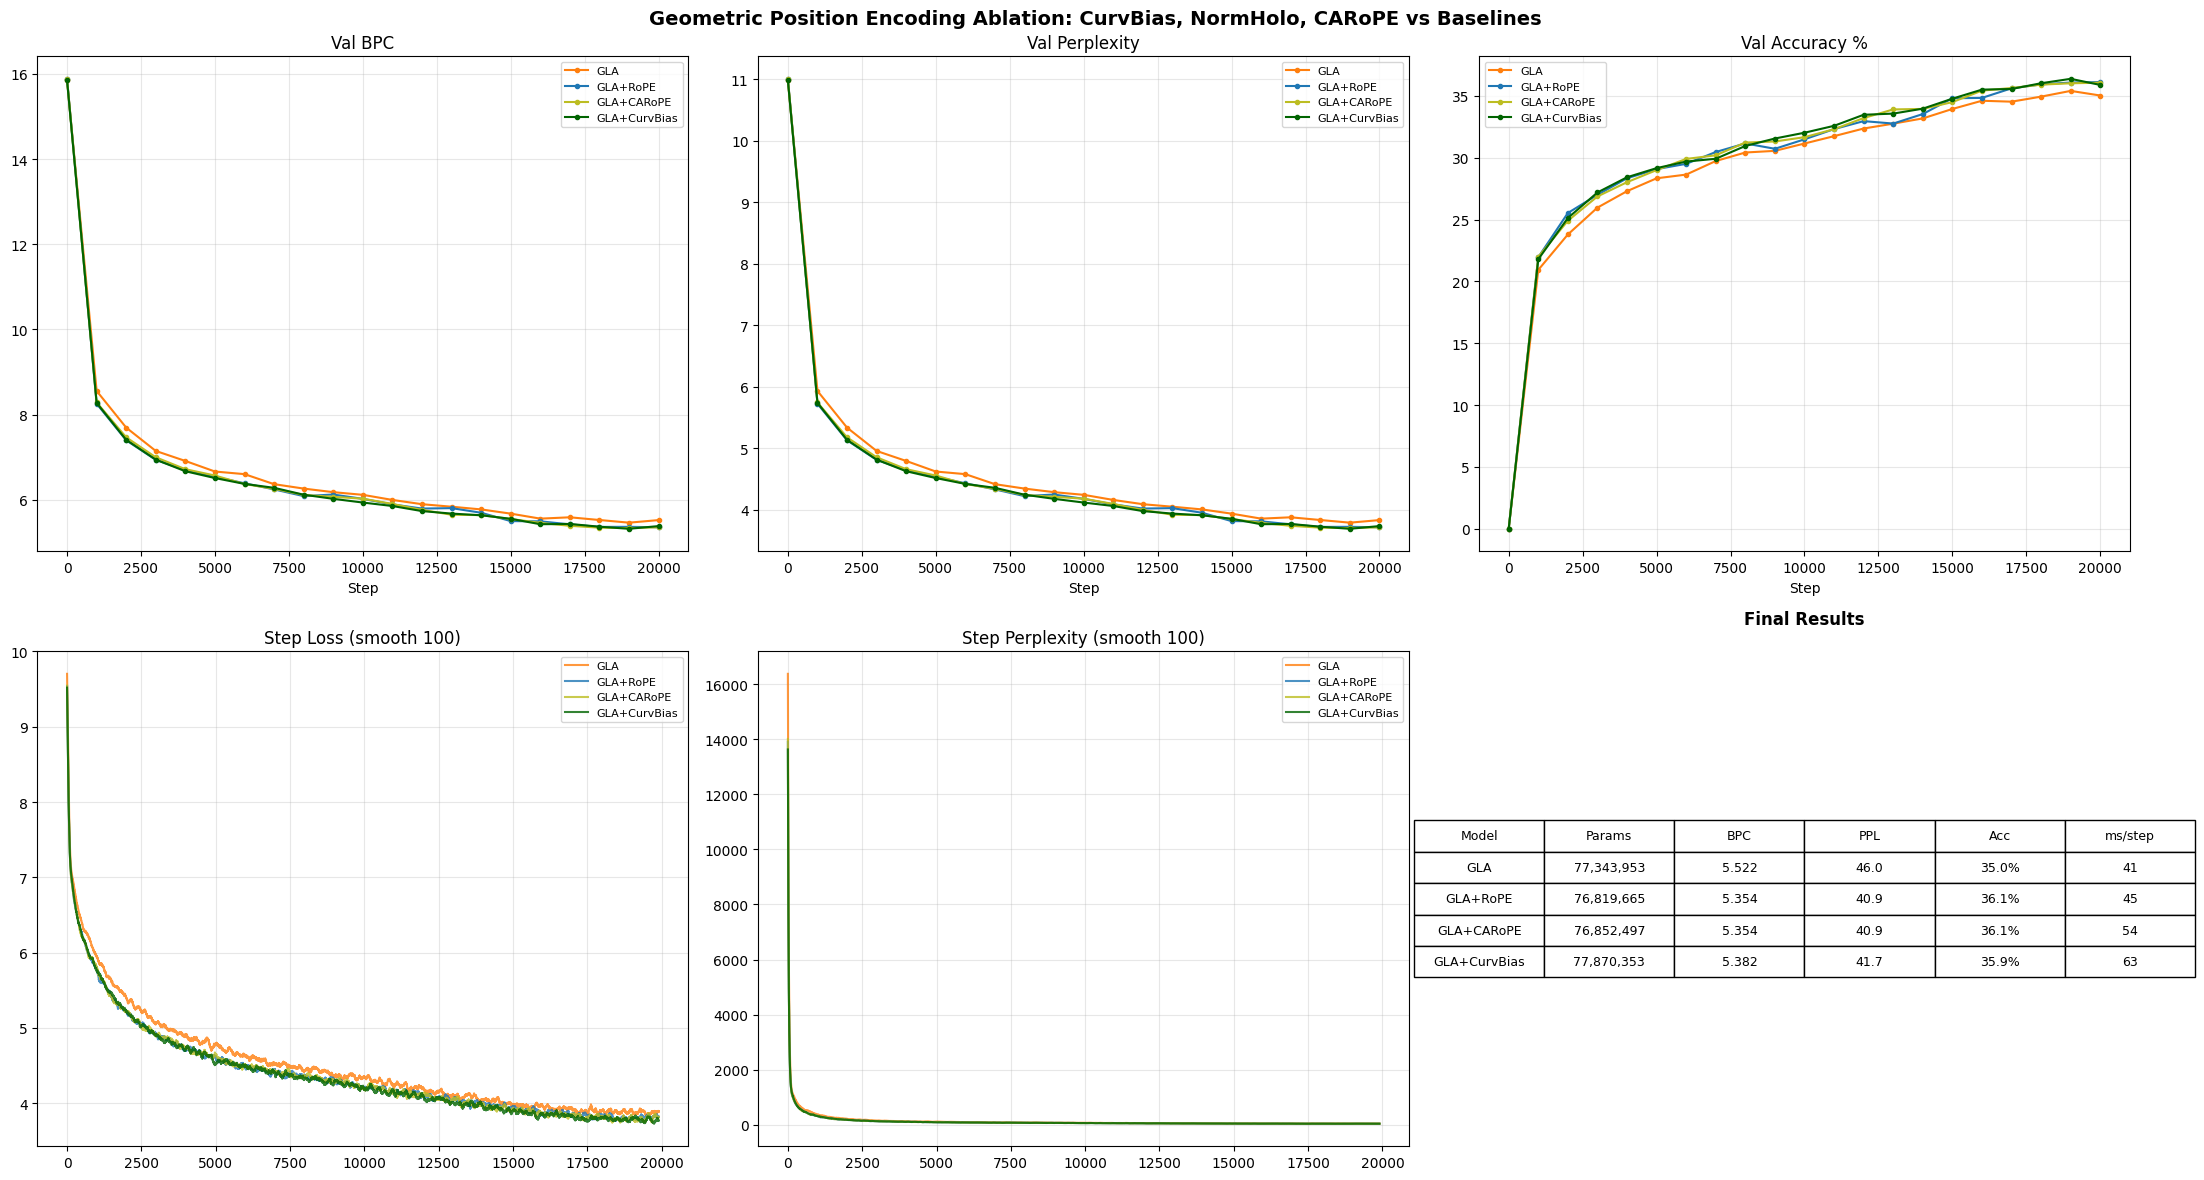


V5 ABLATION RESULTS: Non-Abelian Holonomic RoPE
  GLA                BPC:5.522  PPL:46.0  Params:77,343,953  41ms/step
  GLA+RoPE           BPC:5.354  PPL:40.9  Params:76,819,665  45ms/step
  GLA+CARoPE         BPC:5.354  PPL:40.9  Params:76,852,497  54ms/step
  GLA+CurvBias       BPC:5.382  PPL:41.7  Params:77,870,353  63ms/step


In [30]:
colors = {
    'GPT': 'black', 'GPT+RoPE': 'gray', 'GPT+CARoPE': 'tab:pink',
    'GPT+CDRoPE': 'tab:purple', 'GPT+HoloRoPE': 'tab:red',
    'GPT+CurvBias': 'darkviolet', 'GPT+NormHolo': 'crimson',
    'GLA': 'tab:orange', 'GLA+RoPE': 'tab:blue', 'GLA+CARoPE': 'tab:olive',
    'GLA+CurvBias': 'darkgreen', 'GLA+NormHolo': 'teal',
}
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Geometric Position Encoding Ablation: CurvBias, NormHolo, CARoPE vs Baselines',
             fontsize=14, fontweight='bold')

for ax, key, title in [(axes[0,0], 'val_bpc', 'Val BPC'),
                        (axes[0,1], 'val_ce', 'Val Perplexity'),
                        (axes[0,2], 'val_acc', 'Val Accuracy %')]:
    for name, h in all_hist.items():
        if 'ppl' in title.lower():
            y = [math.exp(min(ce, 20)) for ce in h[key]]
        elif 'acc' in title.lower():
            y = [a * 100 for a in h[key]]
        else:
            y = h[key]
        ax.plot(h['step'], y, '-o', color=colors[name], label=name, markersize=3)
    ax.set_xlabel('Step'); ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

w = 100
for ax, use_ppl in [(axes[1,0], False), (axes[1,1], True)]:
    for name, h in all_hist.items():
        if len(h['per_step_loss']) > w:
            sm = np.convolve(h['per_step_loss'], np.ones(w)/w, mode='valid')
            y = [math.exp(min(x, 20)) for x in sm] if use_ppl else sm
            ax.plot(range(len(y)), y, '-', color=colors[name], label=name, alpha=0.8)
    ax.set_title(f'Step {"Perplexity" if use_ppl else "Loss"} (smooth {w})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Summary table
ax = axes[1, 2]; ax.axis('off')
rows = []
for name, h in all_hist.items():
    ppl = math.exp(min(h['val_ce'][-1], 20))
    rows.append([name, f"{h['n_params']:,}", f"{h['val_bpc'][-1]:.3f}",
                 f"{ppl:.1f}", f"{h['val_acc'][-1]:.1%}", f"{h['avg_step_ms']:.0f}"])
t = ax.table(cellText=rows, colLabels=['Model', 'Params', 'BPC', 'PPL', 'Acc', 'ms/step'],
             loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.2, 1.6)
ax.set_title('Final Results', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('v5_ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 70)
print('V5 ABLATION RESULTS: Non-Abelian Holonomic RoPE')
print('=' * 70)
for name, h in all_hist.items():
    ppl = math.exp(min(h['val_ce'][-1], 20))
    print(f"  {name:<18} BPC:{h['val_bpc'][-1]:.3f}  PPL:{ppl:.1f}  "
          f"Params:{h['n_params']:,}  {h['avg_step_ms']:.0f}ms/step")

## Gap Analysis

In [31]:
def get_ppl(name):
    return math.exp(min(all_hist[name]['val_ce'][-1], 20))

ppls = {name: get_ppl(name) for name in all_hist}

print("\nKey comparisons (PPL, lower is better):")
print("=" * 60)

def ppl_cmp(a, b):
    if a in ppls and b in ppls:
        d = ppls[a] - ppls[b]
        print(f"  {b} vs {a}: {d:+.1f} ({d/ppls[a]*100:+.1f}%)")

print("\n--- Content-dependence vs baselines ---")
ppl_cmp('GPT', 'GPT+CARoPE')
ppl_cmp('GPT', 'GPT+CDRoPE')
ppl_cmp('GLA', 'GLA+CARoPE')
ppl_cmp('GLA', 'GLA+CDRoPE')
ppl_cmp('GLA+RoPE', 'GLA+CARoPE')
ppl_cmp('GLA+RoPE', 'GLA+CDRoPE')

print("\n--- CDRoPE vs CARoPE (our formulation vs theirs) ---")
ppl_cmp('GPT+CARoPE', 'GPT+CDRoPE')
ppl_cmp('GLA+CARoPE', 'GLA+CDRoPE')

print("\n--- Non-abelian vs abelian (HoloRoPE vs CDRoPE) --- THE KEY QUESTION ---")
ppl_cmp('GPT+CDRoPE', 'GPT+HoloRoPE')
ppl_cmp('GLA+CDRoPE', 'GLA+HoloRoPE')

print("\n--- Non-abelian vs CARoPE (HoloRoPE vs CARoPE) ---")
ppl_cmp('GPT+CARoPE', 'GPT+HoloRoPE')
ppl_cmp('GLA+CARoPE', 'GLA+HoloRoPE')

print("\n--- Cross-architecture ---")
best_linear = min([ppls.get(n, 999) for n in ['GLA+RoPE','GLA+CARoPE','GLA+CDRoPE','GLA+HoloRoPE']])
best_softmax = min([ppls.get(n, 999) for n in ['GPT','GPT+CARoPE','GPT+CDRoPE','GPT+HoloRoPE']])
print(f"  Best linear PPL:  {best_linear:.1f}")
print(f"  Best softmax PPL: {best_softmax:.1f}")
print(f"  Gap: {best_linear - best_softmax:+.1f}")

print("\n--- Ranking ---")
ranked = sorted(ppls.items(), key=lambda x: x[1])
for i, (name, ppl) in enumerate(ranked):
    print(f"  {i+1}. {name:<18} PPL: {ppl:.1f}")


Key comparisons (PPL, lower is better):

--- Content-dependence vs baselines ---
  GLA+CARoPE vs GLA: +5.1 (+11.0%)
  GLA+CARoPE vs GLA+RoPE: -0.0 (-0.1%)

--- CDRoPE vs CARoPE (our formulation vs theirs) ---

--- Non-abelian vs abelian (HoloRoPE vs CDRoPE) --- THE KEY QUESTION ---

--- Non-abelian vs CARoPE (HoloRoPE vs CARoPE) ---

--- Cross-architecture ---
  Best linear PPL:  40.9
  Best softmax PPL: 999.0
  Gap: -958.1

--- Ranking ---
  1. GLA+RoPE           PPL: 40.9
  2. GLA+CARoPE         PPL: 40.9
  3. GLA+CurvBias       PPL: 41.7
  4. GLA                PPL: 46.0


## Diagnostics: Training Curve Analysis

Compare convergence speed and final performance across all position encoding methods.
Results loaded from saved JSON — no model checkpoints needed.

/tmp/ipykernel_56293/2997257277.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
/tmp/ipykernel_56293/2997257277.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(True, alpha=0.3)


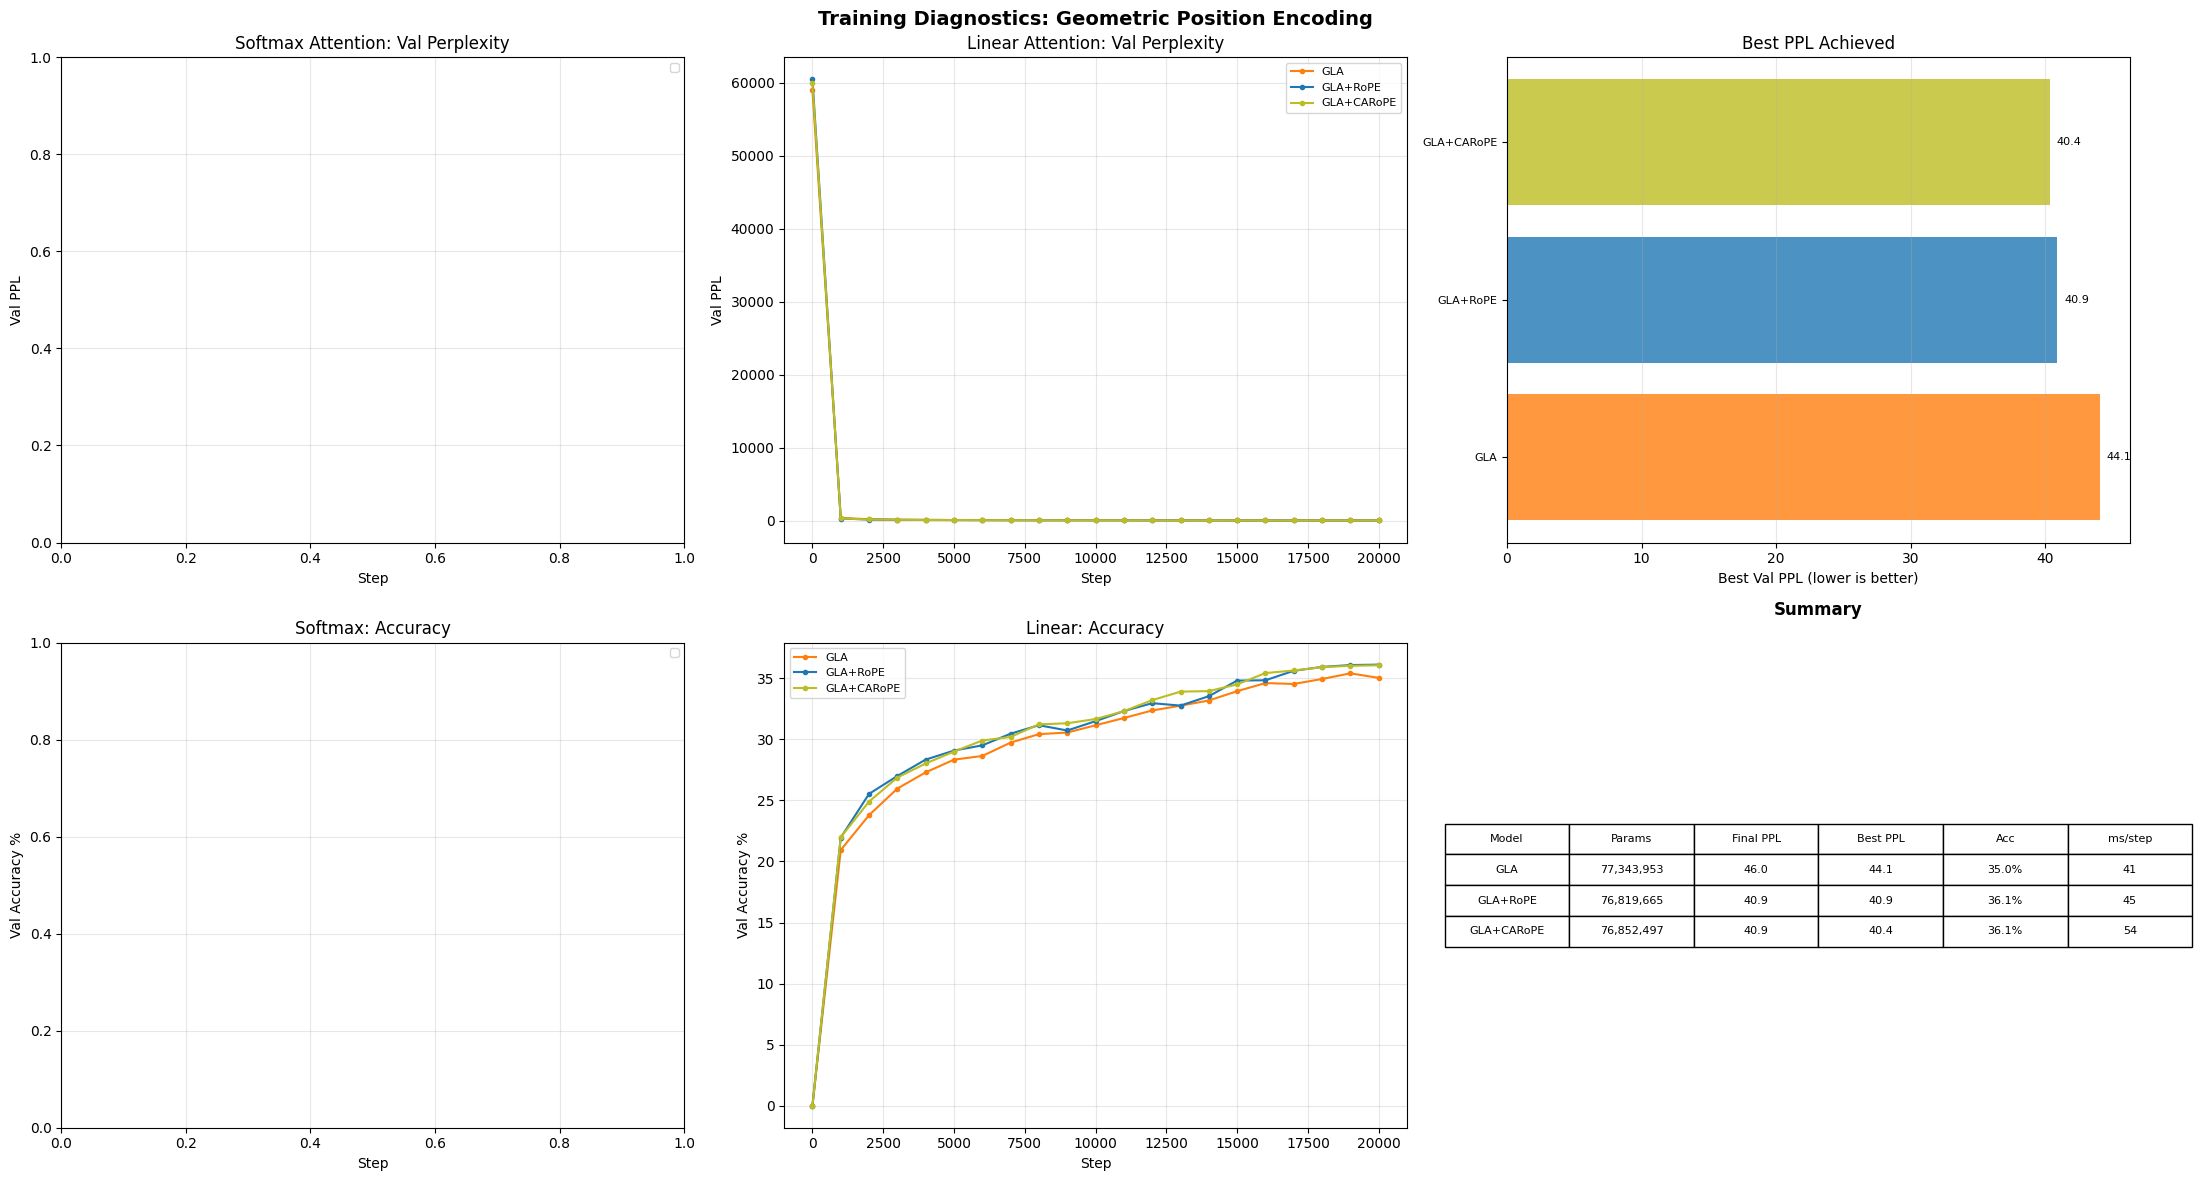

In [32]:
# Can also reload from disk if runtime restarted:
# all_hist = {}
# for f in os.listdir(RESULTS_DIR):
#     if f.endswith('.json') and f != 'all_hist.json':
#         name = f.replace('.json', '')
#         with open(os.path.join(RESULTS_DIR, f)) as fh:
#             all_hist[name] = _json.load(fh)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Training Diagnostics: Geometric Position Encoding', fontsize=14, fontweight='bold')

# --- 1. Softmax attention comparison ---
ax = axes[0, 0]
for name in ['GPT', 'GPT+CARoPE', 'GPT+CDRoPE', 'GPT+HoloRoPE']:
    if name in all_hist:
        h = all_hist[name]
        ppl = [math.exp(min(ce, 20)) for ce in h['val_ce']]
        ax.plot(h['step'], ppl, '-o', color=colors.get(name, 'gray'), label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('Val PPL')
ax.set_title('Softmax Attention: Val Perplexity')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 2. Linear attention comparison ---
ax = axes[0, 1]
for name in ['GLA', 'GLA+RoPE', 'GLA+CARoPE', 'GLA+CDRoPE', 'GLA+HoloRoPE']:
    if name in all_hist:
        h = all_hist[name]
        ppl = [math.exp(min(ce, 20)) for ce in h['val_ce']]
        ax.plot(h['step'], ppl, '-o', color=colors.get(name, 'gray'), label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('Val PPL')
ax.set_title('Linear Attention: Val Perplexity')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 3. Best PPL per method (bar chart) ---
ax = axes[0, 2]
names_ordered = ['GPT', 'GPT+CARoPE', 'GPT+CDRoPE', 'GPT+HoloRoPE',
                 'GLA', 'GLA+RoPE', 'GLA+CARoPE', 'GLA+CDRoPE', 'GLA+HoloRoPE']
best_ppls = []
bar_colors = []
bar_names = []
for name in names_ordered:
    if name in all_hist:
        h = all_hist[name]
        best = min(math.exp(min(ce, 20)) for ce in h['val_ce'])
        best_ppls.append(best)
        bar_colors.append(colors.get(name, 'gray'))
        bar_names.append(name)
if best_ppls:
    bars = ax.barh(range(len(bar_names)), best_ppls, color=bar_colors, alpha=0.8)
    ax.set_yticks(range(len(bar_names)))
    ax.set_yticklabels(bar_names, fontsize=8)
    ax.set_xlabel('Best Val PPL (lower is better)')
    ax.set_title('Best PPL Achieved')
    for i, v in enumerate(best_ppls):
        ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='x')

# --- 4. Accuracy curves (softmax) ---
ax = axes[1, 0]
for name in ['GPT', 'GPT+CARoPE', 'GPT+CDRoPE', 'GPT+HoloRoPE']:
    if name in all_hist:
        h = all_hist[name]
        ax.plot(h['step'], [a*100 for a in h['val_acc']], '-o',
                color=colors.get(name, 'gray'), label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('Val Accuracy %')
ax.set_title('Softmax: Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 5. Accuracy curves (linear) ---
ax = axes[1, 1]
for name in ['GLA', 'GLA+RoPE', 'GLA+CARoPE', 'GLA+CDRoPE', 'GLA+HoloRoPE']:
    if name in all_hist:
        h = all_hist[name]
        ax.plot(h['step'], [a*100 for a in h['val_acc']], '-o',
                color=colors.get(name, 'gray'), label=name, markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('Val Accuracy %')
ax.set_title('Linear: Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 6. Summary table ---
ax = axes[1, 2]; ax.axis('off')
summary = []
for name in names_ordered:
    if name in all_hist:
        h = all_hist[name]
        final_ppl = math.exp(min(h['val_ce'][-1], 20))
        best_ppl = min(math.exp(min(ce, 20)) for ce in h['val_ce'])
        summary.append([name, f"{h.get('n_params','?'):,}" if isinstance(h.get('n_params'), int) else '?',
                        f"{final_ppl:.1f}", f"{best_ppl:.1f}",
                        f"{h['val_acc'][-1]:.1%}", f"{h.get('avg_step_ms',0):.0f}"])
if summary:
    t = ax.table(cellText=summary,
                 colLabels=['Model', 'Params', 'Final PPL', 'Best PPL', 'Acc', 'ms/step'],
                 loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1.2, 1.6)
ax.set_title('Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('v5_ablation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()